In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
# Specify the paths to the directories containing the ene*.dat files
data_directory1 = '/home/adurden/Ari/TAB/m9_1000_split/adiabatic/1/data'
data_directory2 = '/home/adurden/Ari/TAB/m9_1000_split/pointer/1/data'

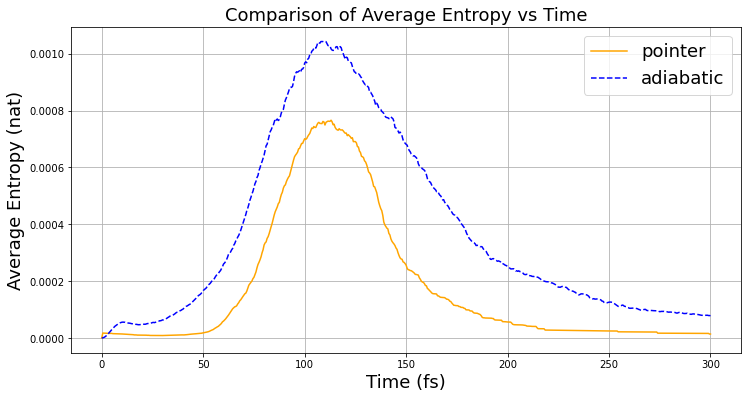

Number of files processed in Dataset 1: 500
Number of files processed in Dataset 2: 1000
Time range Dataset 1: 0.0 to 300.0
Time range Dataset 2: 0.0 to 300.0
Average entropy at start (Dataset 1): 0.0
Average entropy at end (Dataset 1): 1.3913508375000012e-05
Average entropy at start (Dataset 2): 0.0
Average entropy at end (Dataset 2): 7.821582446250007e-05


In [27]:


def process_data(directory):
    columns = ["t", "Mean-Field Energy", "PE Difference", "Total Energy", "norm", "last_column", "total count"]
    file_paths = glob.glob(os.path.join(directory, 'ene*.dat'))
    dfs = []

    for file_path in file_paths:
        df = pd.read_csv(file_path, delim_whitespace=True, names=columns, skiprows=1)
        dfs.append(df)

    combined_df = pd.concat(dfs)
    average_df = combined_df.groupby('t').mean().reset_index()
    return average_df, len(file_paths)



# Process data from both directories
avg_df1, file_count1 = process_data(data_directory1)
avg_df2, file_count2 = process_data(data_directory2)

# Plot the data
plt.figure(figsize=(12, 6))
#set legend font size to 18

plt.plot(avg_df1['t'], (9/8)*avg_df1['last_column'], linestyle='-', label='pointer', color='orange')
plt.plot(avg_df2['t'], (9/8)*avg_df2['last_column'], linestyle='--', label='adiabatic', color='blue')
plt.xlabel('Time (fs)', fontsize=18)
plt.ylabel('Average Entropy (nat)', fontsize=18)
plt.title('Comparison of Average Entropy vs Time', fontsize=18)
plt.legend(fontsize=18)
plt.grid(True)
plt.savefig('entropy_comparison.pdf', format='pdf')
plt.show()
# Print some statistics
print(f"Number of files processed in Dataset 1: {file_count1}")
print(f"Number of files processed in Dataset 2: {file_count2}")
print(f"Time range Dataset 1: {avg_df1['t'].min()} to {avg_df1['t'].max()}")
print(f"Time range Dataset 2: {avg_df2['t'].min()} to {avg_df2['t'].max()}")
print(f"Average entropy at start (Dataset 1): {(9/8)*avg_df1['last_column'].iloc[0]}")
print(f"Average entropy at end (Dataset 1): {(9/8)*avg_df1['last_column'].iloc[-1]}")
print(f"Average entropy at start (Dataset 2): {(9/8)*avg_df2['last_column'].iloc[0]}")
print(f"Average entropy at end (Dataset 2): {(9/8)*avg_df2['last_column'].iloc[-1]}")

1000
1000
     t    S0 pop    S1 pop    S2 pop    S3 pop    S4 pop    S5 pop    S6 pop  \
0  1.0  0.999807  0.000026  0.000026  0.000026  0.000026  0.000026  0.000026   
1  2.0  0.999248  0.000101  0.000101  0.000101  0.000101  0.000099  0.000098   
2  3.0  0.998387  0.000221  0.000220  0.000219  0.000218  0.000208  0.000206   
3  4.0  0.997321  0.000375  0.000372  0.000369  0.000366  0.000336  0.000332   
4  5.0  0.996168  0.000552  0.000545  0.000538  0.000531  0.000463  0.000455   

     S7 pop    S8 pop  poptot  
0  0.000026  0.000026     NaN  
1  0.000098  0.000098     NaN  
2  0.000205  0.000204     NaN  
3  0.000328  0.000324     NaN  
4  0.000447  0.000439     NaN  


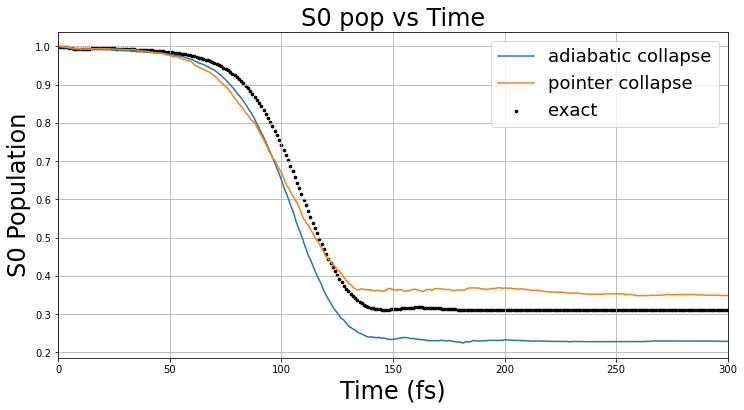

In [38]:
# Define the column names

def process_data2(directory):
    columns2 = ["t", "S0 pop", "S1 pop", "S2 pop", "S3 pop", "S4 pop", "S5 pop", "S6 pop", "S7 pop", "S8 pop", "poptot"]
    file_paths = glob.glob(os.path.join(directory, 'dpop*.dat'))
    dfs = []        
    count=0
    for file_path in file_paths:
        df = pd.read_csv(file_path, delim_whitespace=True, names=columns2, skiprows=1)
        dfs.append(df)
        count+=1
    print(count)
    combined_df = pd.concat(dfs)
    average_df = combined_df.groupby('t').mean().reset_index()
    return average_df, len(file_paths)
avg_df1, file_count1 = process_data2(data_directory1)
avg_df2, file_count2 = process_data2(data_directory2)
#avg_df3, file_count3 = process_data2(data_directory3)
# Plot the data

# Load pop.dat with 1-second interval data
columns_pop = ["t", "S0 pop", "S1 pop", "S2 pop", "S3 pop", "S4 pop", "S5 pop", "S6 pop", "S7 pop", "S8 pop", "poptot"]
pop_df = pd.read_csv('/home/adurden/Ari/TAB/m9_1000_split/pop.dat', delim_whitespace=True, names=columns_pop, index_col=False)
pop_df['t'] = pop_df['t'] / 100
print(pop_df.head())
# Plot the dat



plt.figure(figsize=(12, 6))
plt.plot(avg_df1['t'], avg_df1['S0 pop'], label='adiabatic collapse')
plt.plot(avg_df2['t'], avg_df2['S0 pop'], label='pointer collapse')
#plt.plot(avg_df3['t'], avg_df3['S0 pop'], label='rescales all directions')
plt.scatter(pop_df['t'], pop_df['S0 pop'], label='exact', color='black', marker='o', s=7)  # Plot as dots with smaller size
plt.xlabel('Time (fs)', fontsize=24)
plt.ylabel('S0 Population', fontsize=24)

#plot x axis up to 300 fs
plt.xlim(0, 300)

plt.title('S0 pop vs Time', fontsize=24)
plt.legend(fontsize=18)
plt.grid(True)
plt.savefig('S0_pop_m9_1000_split.pdf', format='pdf')
plt.show()